In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
df = pd.read_csv("loan.csv")
df.head(3)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y


# * Handling Null Values

In [3]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [4]:
(df.isnull().sum() / df.shape[0]) * 100

Loan_ID              0.000000
Gender               2.117264
Married              0.488599
Dependents           2.442997
Education            0.000000
Self_Employed        5.211726
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           3.583062
Loan_Amount_Term     2.280130
Credit_History       8.143322
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

# i) Handling Null values in Categorical column

In [5]:
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

C:\Users\user\AppData\Local\Temp\ipykernel_14000\3486712827.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


# ii) Handling Null values in Numerical column

In [6]:
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

In [7]:
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df.drop(['ApplicantIncome','CoapplicantIncome'], axis=1, inplace=True)

# * Categorical Encoding

In [8]:
df1 = df[["Gender", "Married", "Education", "Self_Employed", "Property_Area"]]
df1.head(2)

,Gender,Married,Education,Self_Employed,Property_Area
0,Male,No,Graduate,No,Urban
1,Male,Yes,Graduate,No,Rural


In [9]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(drop="first") # USING DUMMY ENCODING, drop="first" --> Drops the first variable of one type without affecting the rest
enc_arr = ohe.fit_transform(df1).toarray() # 'fit_transform', fit --> understands the data, transform --> converts data from categorical to numerical 
enc_arr

array([[1., 0., 0., 0., 0., 1.],
       [1., 1., 0., 0., 0., 0.],
       [1., 1., 0., 1., 0., 1.],
       ...,
       [1., 1., 0., 0., 0., 1.],
       [1., 1., 0., 0., 0., 1.],
       [0., 0., 0., 1., 1., 0.]], shape=(614, 6))

In [10]:
enc_df = pd.DataFrame(enc_arr, columns=['Gender_Male', 'Married_Yes', 'Education_Not Graduate', 'Self_Employed_Yes', 
                                        'Property_Area_Semiurban', 'Property_Area_Urban'])
enc_df.head(2)

,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,1.0,0.0,0.0,0.0,0.0,1.0
1,1.0,1.0,0.0,0.0,0.0,0.0


In [11]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(df['Loan_Status'])

LabelEncoder()

In [12]:
df['Loan_Status'] = le.transform(df['Loan_Status'])

In [13]:
from sklearn.preprocessing import OrdinalEncoder

ord_data = [["0", "1", "2", "3+"]] # here we 2 square brackets, coz here 2-D array is needed

oe = OrdinalEncoder(categories=ord_data) # categories=ord_data, is done to keep the data for the given column ORDER-WISE, else the order will be distrurbed as OrdinalEncoder arranges it ALPHABETICAL-WISE
oe.fit(df[["Dependents"]])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute.","[['0', '1', ...]]"
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'use_encoded_value'}, default='error'When set to 'error' an error will be raised in case an unknowncategorical feature is present during transform. When set to'use_encoded_value', the encoded value of unknown categories will beset to the value given for the parameter `unknown_value`. In:meth:`inverse_transform`, an unknown category will be denoted as None... versionadded:: 0.24",'error'
,"unknown_value unknown_value: int or np.nan, default=NoneWhen the parameter handle_unknown is set to 'use_encoded_value', thisparameter is required and will set the encoded value of unknowncategories. It has to be distinct from the values used to encode any ofthe categories in `fit`. If set to np.nan, the `dtype` parameter mustbe a float dtype... versionadded:: 0.24",None
,"encoded_missing_value encoded_missing_value: int or np.nan, default=np.nanEncoded value of missing categories. If set to `np.nan`, then the `dtype`parameter must be a float dtype... versionadded:: 1.1",nan
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.3 Read more in the :ref:`User Guide `.",None
,"max_categories max_categories: int, default=NoneSpecifies an upper limit to the number of output categories for each inputfeature when considering infrequent categories. If there are infrequentcategories, `max_categories` includes the category representing theinfrequent categories along with the frequent categories. If `None`,there is no limit to the number of output features.`max_categories` do **not** take into account missing or unknowncategories. Setting `unknown_value` or `encoded_missing_value` to aninteger will increase the number of unique integer codes by one each.This can result in up to `max_categories + 2` integer codes... versionadded:: 1.3 Read more in the :ref:`User Guide `.",None


In [14]:
df["Dependents"]  = oe.transform(df[["Dependents"]])

## Creating a new dataset after encoding

In [15]:
df_new = enc_df

In [16]:
df_new[["Dependents", "Total_Income", "LoanAmount", "Loan_Amount_Term", "Credit_History", "Loan_Status"]] = df[["Dependents", "Total_Income", "LoanAmount", "Loan_Amount_Term", "Credit_History", "Loan_Status"]]

In [17]:
df_new.head(2)

,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,Dependents,Total_Income,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,5849.0,128.0,360.0,1.0,1
1,1.0,1.0,0.0,0.0,0.0,0.0,1.0,6091.0,128.0,360.0,1.0,0


# * Handling Outliers

In [18]:
df.describe()

,Dependents,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Total_Income
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,0.744300,145.752443,342.410423,0.855049,0.687296,7024.705081
std,1.009623,84.107233,64.428629,0.352339,0.463973,6458.663872
min,0.000000,9.000000,12.000000,0.000000,0.000000,1442.000000
25%,0.000000,100.250000,360.000000,1.000000,0.000000,4166.000000
50%,0.000000,128.000000,360.000000,1.000000,1.000000,5416.500000
75%,1.000000,164.750000,360.000000,1.000000,1.000000,7521.750000
max,3.000000,700.000000,480.000000,1.000000,1.000000,81000.000000


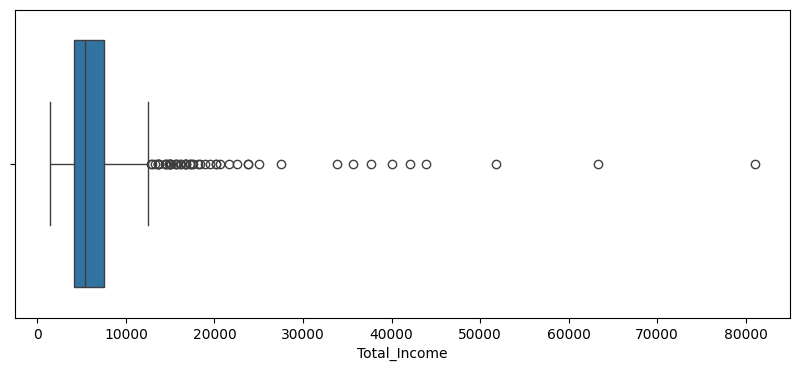

In [19]:
# Checking outliers through boxplot
plt.figure(figsize=(10, 4))
sns.boxplot(x = 'Total_Income', data = df_new)
plt.show()

In [20]:
df_new.shape

(614, 12)

In [21]:
q1 = df_new["Total_Income"].quantile(0.25)
q3 = df_new["Total_Income"].quantile(0.75)
IQR = q3 - q1
IQR

np.float64(3355.75)

In [22]:
min_range = q1 - (1.5*IQR)
max_range = q3 + (1.5*IQR)
min_range, max_range

(np.float64(-867.625), np.float64(12555.375))

In [23]:
df_new = df_new[df_new["Total_Income"] <= max_range]
df_new.shape

(564, 12)

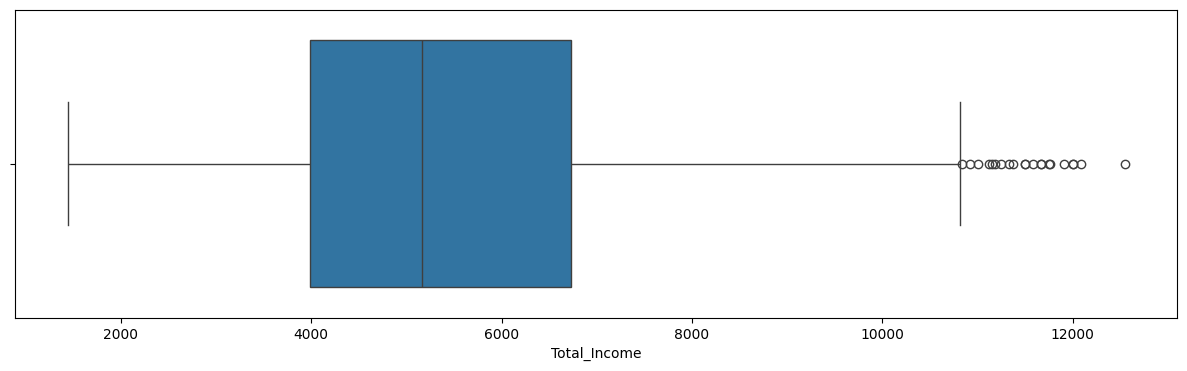

In [24]:
plt.figure(figsize=(15, 4))
sns.boxplot(x = 'Total_Income', data = df_new)
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_14000\3952506823.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Total_Income"])
C:\Users\user\AppData\Local\Temp\ipykernel_14000\3952506823.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_new["Total_Income"])


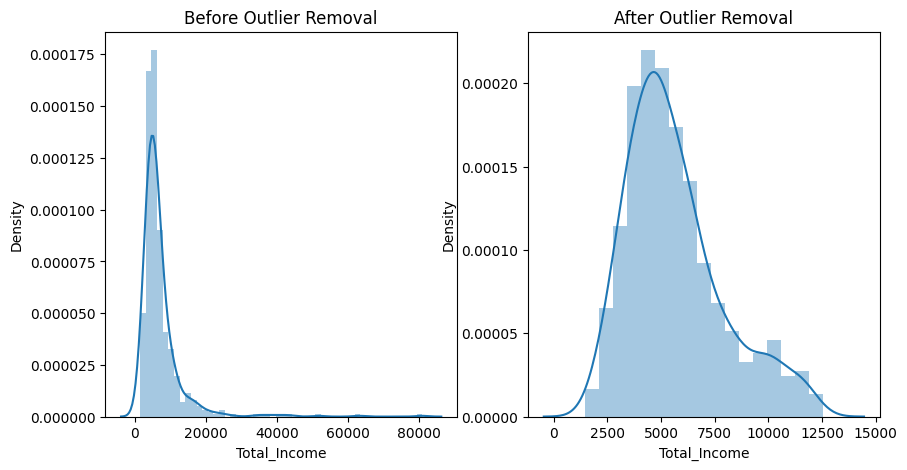

In [25]:
plt.figure(figsize=(10, 5))

# Before Outlier Removal
plt.subplot(1,2,1) # Means giving the just below plot in the 1st position (i.e. ( , ,1)) with the Single row(i.e. (1, , ), 2 column division(i.e. (,2 ,)) 
plt.title("Before Outlier Removal")
sns.distplot(df["Total_Income"])

# After Outlier Removal
plt.subplot(1,2,2) # Means giving the just below plot in the 1st position (i.e. ( , ,2)) with the Single row(i.e. (1, , ), 2 column division(i.e. (,2 ,)) 
plt.title("After Outlier Removal")
sns.distplot(df_new["Total_Income"])

plt.show()

# * FEATURE SCALING

Scaling is done to bring all numerical features to the same range, so that no feature dominates others during model training.

And it is done after splitting(Test-Train split) to prevent data leakage.

E.g. If we have 2 apples, one of a bigger size and the other of the smaller size; we know both have same material internally, but still we prefer the bigger apple to buy, as we consider it of more importance. Similar is in the case of a ML model.

In [26]:
# NOTE: There is no change in the distribution pattern of the dataset. And there is no affect on outliers as well.

### Feature Scaling types:-
i) Standardization (using StandardScaler)

ii) Normalization (using MinMaxScaler)

# i) Standardization 
###### Mean becomes 0
###### Standard deviation becomes 1
###### Data is centered around zero (origin in graph)

##### Here values can be -ve

In [27]:
df_new.describe()

,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,Dependents,Total_Income,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status
count,564.000000,564.000000,564.000000,564.000000,564.000000,564.000000,564.000000,564.000000,564.000000,564.000000,564.000000,564.000000
mean,0.813830,0.648936,0.234043,0.117021,0.384752,0.328014,0.718085,5630.834965,132.647163,342.553191,0.856383,0.693262
std,0.389589,0.477727,0.423775,0.321731,0.486968,0.469907,0.992132,2256.779884,54.351151,64.959113,0.351012,0.461549
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1442.000000,9.000000,12.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3986.250000,100.000000,360.000000,1.000000,0.000000
50%,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5166.500000,126.500000,360.000000,1.000000,1.000000
75%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,6724.500000,158.000000,360.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,12543.000000,496.000000,480.000000,1.000000,1.000000


In [28]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(df_new[["Total_Income"]])

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [29]:
ss.transform(df_new[["Total_Income"]])

array([[ 9.67567565e-02],
       [ 2.04084381e-01],
       [-1.16678210e+00],
       [-3.05943588e-01],
       [ 1.63725646e-01],
       [ 1.76610047e+00],
       [-7.90248407e-01],
       [-4.02855413e-02],
       [-4.38335619e-02],
       [-7.67629776e-01],
       [-5.72488640e-01],
       [ 2.46062552e+00],
       [-4.15932228e-01],
       [-1.43953619e+00],
       [-3.01952065e-01],
       [-9.02454560e-01],
       [-9.40595782e-01],
       [-3.29892727e-01],
       [ 2.08075905e-01],
       [ 8.99939932e-01],
       [ 2.63847005e+00],
       [-4.96649698e-01],
       [-1.54709207e-01],
       [ 4.48454304e-01],
       [ 1.74259484e+00],
       [-2.56714801e-01],
       [-1.61805249e-01],
       [-1.85775912e+00],
       [ 8.96607152e-02],
       [ 8.44502110e-01],
       [-1.09271717e+00],
       [-4.16375731e-01],
       [-2.05712004e-01],
       [-5.71601634e-01],
       [-1.09670869e+00],
       [-2.23895610e-01],
       [ 2.54799553e+00],
       [-9.52798614e-02],
       [-9.0

In [30]:
# Creating a new column "Total_Income_ss"
df_new["Total_Income_ss"] = pd.DataFrame(ss.transform(df_new[["Total_Income"]]), columns=["x"])

In [31]:
df_new.head(3)

,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,Dependents,Total_Income,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Total_Income_ss
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,5849.0,128.0,360.0,1.0,1,0.096757
1,1.0,1.0,0.0,0.0,0.0,0.0,1.0,6091.0,128.0,360.0,1.0,0,0.204084
2,1.0,1.0,0.0,1.0,0.0,1.0,0.0,3000.0,66.0,360.0,1.0,1,-1.166782


In [32]:
df_new.describe()

,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,Dependents,Total_Income,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Total_Income_ss
count,564.000000,564.000000,564.000000,564.000000,564.000000,564.000000,564.000000,564.000000,564.000000,564.000000,564.000000,564.000000,518.000000
mean,0.813830,0.648936,0.234043,0.117021,0.384752,0.328014,0.718085,5630.834965,132.647163,342.553191,0.856383,0.693262,0.001000
std,0.389589,0.477727,0.423775,0.321731,0.486968,0.469907,0.992132,2256.779884,54.351151,64.959113,0.351012,0.461549,0.998102
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1442.000000,9.000000,12.000000,0.000000,0.000000,-1.857759
25%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3986.250000,100.000000,360.000000,1.000000,0.000000,-0.724388
50%,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5166.500000,126.500000,360.000000,1.000000,1.000000,-0.215026
75%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,6724.500000,158.000000,360.000000,1.000000,1.000000,0.500011
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,12543.000000,496.000000,480.000000,1.000000,1.000000,3.065563


In [33]:
# We see that
# Mean --> 0
# Standard Devidation(std) --> 1
# Variance is the SQUARE of std, so variance --> 1^2 = 1

### Checking nature of data Before and After Scaling

C:\Users\user\AppData\Local\Temp\ipykernel_14000\2455574142.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_new["Total_Income"])
C:\Users\user\AppData\Local\Temp\ipykernel_14000\2455574142.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_new["Total_Income_ss"])


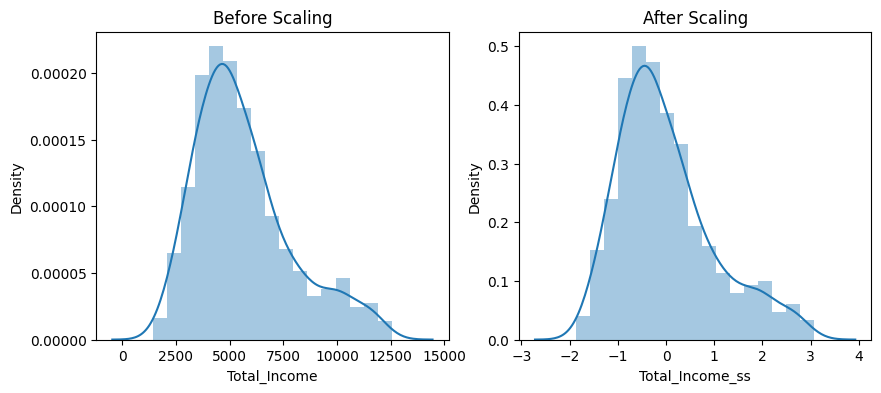

In [34]:
plt.figure(figsize=(10, 4))

# Before Scaling
plt.subplot(1,2,1) # Means giving the just below plot in the 1st position (i.e. ( , ,1)) with the Single row(i.e. (1, , ), 2 column division(i.e. (,2 ,)) 
plt.title("Before Scaling")
sns.distplot(df_new["Total_Income"])

# After Scaling
plt.subplot(1,2,2) # Means giving the just below plot in the 1st position (i.e. ( , ,2)) with the Single row(i.e. (1, , ), 2 column division(i.e. (,2 ,)) 
plt.title("After Scaling")
sns.distplot(df_new["Total_Income_ss"])

plt.show()

In [35]:
# We observe that there is no change in the NATURE of the graph, just the MAGNITUDE of the graph changes
# Preserves original distribution shape

# ii) Normalization
###### Minimum value becomes 0

###### Maximum value becomes 1

##### Here values lies btw 0 and 1

In [36]:
from sklearn.preprocessing import MinMaxScaler

In [37]:
ms = MinMaxScaler()
ms.fit(df_new[["Total_Income"]])

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [38]:
df_new["Total_Income_ms"] = ms.transform(df_new[["Total_Income"]])

### Checking nature of data Before and After Scaling

C:\Users\user\AppData\Local\Temp\ipykernel_14000\618095151.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_new["Total_Income"])
C:\Users\user\AppData\Local\Temp\ipykernel_14000\618095151.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_new["Total_Income_ms"])


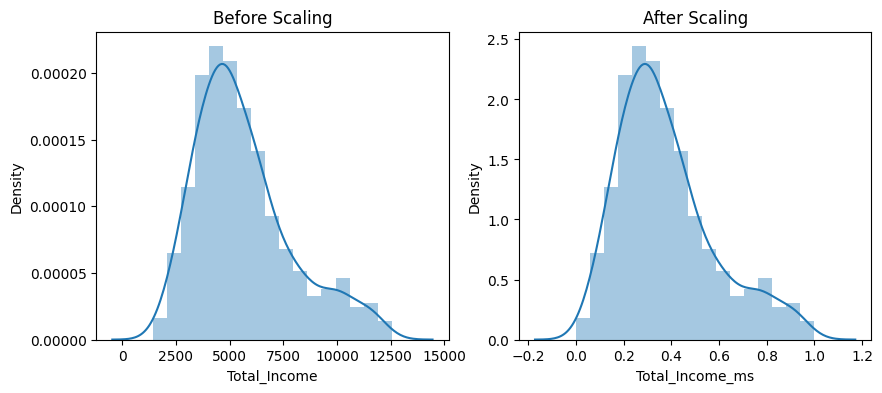

In [39]:
plt.figure(figsize=(10, 4))

# Before Scaling
plt.subplot(1,2,1) # Means giving the just below plot in the 1st position (i.e. ( , ,1)) with the Single row(i.e. (1, , ), 2 column division(i.e. (,2 ,)) 
plt.title("Before Scaling")
sns.distplot(df_new["Total_Income"])

# After Scaling
plt.subplot(1,2,2) # Means giving the just below plot in the 1st position (i.e. ( , ,2)) with the Single row(i.e. (1, , ), 2 column division(i.e. (,2 ,)) 
plt.title("After Scaling")
sns.distplot(df_new["Total_Income_ms"])

plt.show()

# * Function Transformation --> used when dataset is highly skewed
i) To convert a Non-Normal distribution data to a Normal Distribution data

ii) To change data pattern (E.g.: converting metre to cm, converting degree celsius to Kelvin, etc.)

In [1]:
# we have Non-Normal distribution in 'Total_Income' column, so we can apply 'Function Transformation' here

In [41]:
from sklearn.preprocessing import FunctionTransformer
ft = FunctionTransformer(func = np.log1p)
# is mathematically the same as: log(1+x), it is done so that the datapoint gets shifted by 1, log(0) is undefined, and ML algo won't work on it.

In [42]:
ft.fit(df_new[["Total_Income"]])

,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<ufunc 'log1p'>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to func... versionadded:: 0.18",None
,"inv_kw_args inv_kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to inverse_func... versionadded:: 0.18",None


In [43]:
df_new["Total_Income_ft"] = ft.transform(df_new[["Total_Income"]])

C:\Users\user\AppData\Local\Temp\ipykernel_14000\367702768.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_new["Total_Income"])
C:\Users\user\AppData\Local\Temp\ipykernel_14000\367702768.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_new["Total_Income_ft"])


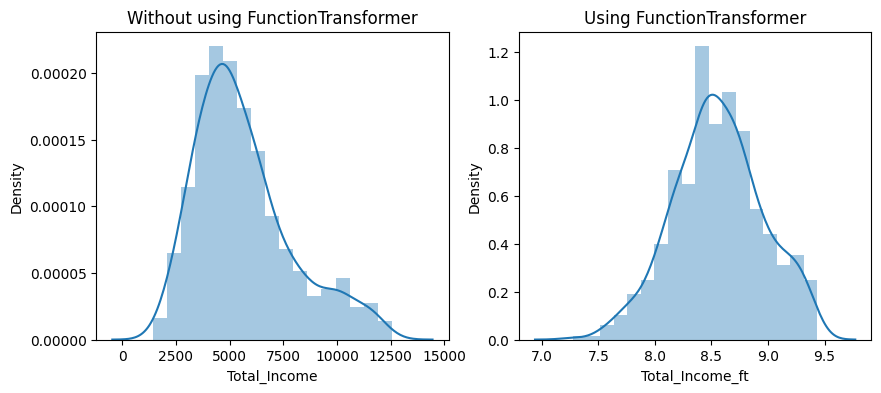

In [44]:
plt.figure(figsize=(10, 4))

# Without using FunctionTransformer
plt.subplot(1,2,1)
plt.title("Without using FunctionTransformer")
sns.distplot(df_new["Total_Income"])

# Using FunctionTransformer
plt.subplot(1,2,2)
plt.title("Using FunctionTransformer")
sns.distplot(df_new["Total_Income_ft"])

plt.show()

In [45]:
# NOTE: When we know that removing OUTLIER can remove an important 'Feature' or 'Row for prediction,
# then we can use the 'FunctionTransformer' without removing the outlier, and the graph would come as Normal Distribution curve